# Free Agent Archetype Explorer
Run cells top to bottom. Step 1 hits the NBA API (~15s), the rest is instant.

In [2]:
import sys, os
# Adjust if your notebook isn't in the notebooks/ folder
sys.path.append(os.path.join(os.getcwd(), '..', 'model'))

## Step 1 — Fetch player stats from the NBA API
Pulls per-game, advanced, and usage stats for all players with 10+ games.
Saves to `data/players_merged.csv` so you only need to do this once.

In [3]:
from fetch_players import merge_and_save, season_str

SEASON_YEAR = 2024  # 2024 = 2024-25 season

df = merge_and_save(season_str(SEASON_YEAR))
print(f"\nLoaded {len(df)} players, {len(df.columns)} columns")
df.head()

Fetching per-game stats for 2024-25...
Fetching advanced stats for 2024-25...
Fetching usage stats for 2024-25...
Fetching physical / bio data...
Saved 508 players → /Users/madhavpudukottaikrishnaraj/Desktop/Github/free_agent_app/model/../data/players_merged.csv

Loaded 508 players, 33 columns


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,...,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,PACE,PIE,POSITION
0,1630639,A.J. Lawson,TOR,24.0,26,18.7,9.1,3.3,1.2,0.5,...,0.036,0.128,0.080,5.7,0.508,0.542,0.189,103.71,0.082,None
1,1631260,AJ Green,MIL,25.0,73,22.7,7.4,2.4,1.5,0.5,...,0.011,0.087,0.051,6.9,0.612,0.621,0.123,100.84,0.058,None
2,1642358,AJ Johnson,WAS,20.0,29,22.0,7.6,2.0,2.6,0.4,...,0.011,0.073,0.042,10.3,0.441,0.480,0.173,100.83,0.053,None
3,203932,Aaron Gordon,DEN,29.0,51,28.4,14.7,4.8,3.2,0.5,...,0.060,0.109,0.086,9.0,0.607,0.650,0.186,101.64,0.104,None
4,1628988,Aaron Holiday,HOU,28.0,62,12.8,5.5,1.3,1.3,0.3,...,0.015,0.073,0.044,9.1,0.571,0.594,0.162,103.09,0.082,None


## Step 2 — Quick look at the data

In [4]:
import pandas as pd

# Check for nulls
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Columns with >10% nulls:")
print(null_pct[null_pct > 10].to_string())

Columns with >10% nulls:
POSITION    100.0


In [5]:
# Distribution of key stats
df[['PTS', 'REB', 'AST', 'TS_PCT', 'USG_PCT', 'MIN']].describe().round(2)

,PTS,REB,AST,TS_PCT,USG_PCT,MIN
count,508.00,508.0,508.00,508.00,508.00,508.00
mean,9.56,3.8,2.22,0.56,0.18,20.57
std,6.54,2.4,1.84,0.07,0.05,9.11
min,0.70,0.2,0.00,0.27,0.07,2.40
25%,4.47,2.1,1.00,0.53,0.14,13.28
50%,8.20,3.3,1.60,0.57,0.17,20.45
75%,12.70,4.9,2.90,0.60,0.21,27.90
max,32.70,13.9,11.60,0.80,0.35,37.70


## Step 3 — Build the KNN model

In [6]:
from knn_model import build_model, find_similar_players, FEATURE_COLS

scaler, knn, X_scaled, valid_df, feature_cols = build_model(df)
print(f"Model built on {len(valid_df)} players")
print(f"Features used ({len(feature_cols)}): {feature_cols}")

Model built on 508 players
Features used (23): ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'OREB', 'DREB', 'TS_PCT', 'EFG_PCT', 'USG_PCT', 'PIE', 'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'OREB_PCT', 'DREB_PCT', 'MIN']


## Step 4 — Find comps for a player
Change `QUERY_PLAYER` to any player name (partial match works).

In [10]:
QUERY_PLAYER = "Luka Dončić"
N_COMPS = 8

comps = find_similar_players(
    QUERY_PLAYER, df, scaler, knn, X_scaled, valid_df, feature_cols, n=N_COMPS
)
comps

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,PTS,REB,AST,TS_PCT,USG_PCT,similarity_distance
0,Jayson Tatum,BOS,27.0,26.8,8.7,6.0,0.582,0.301,2.516739
1,James Harden,LAC,35.0,22.8,5.8,8.7,0.582,0.286,3.074553
2,LeBron James,LAL,40.0,24.4,7.8,8.2,0.604,0.291,3.164173
3,Cade Cunningham,DET,23.0,26.1,6.1,9.1,0.565,0.323,3.502230
4,Anthony Edwards,MIN,23.0,27.6,5.7,4.5,0.595,0.307,3.939652
5,Paolo Banchero,ORL,22.0,25.9,7.5,4.8,0.551,0.330,4.054714
6,Franz Wagner,ORL,23.0,24.2,5.7,4.7,0.558,0.306,4.077566
7,Ja Morant,MEM,25.0,23.2,4.1,7.3,0.563,0.312,4.097866


## Step 5 — Compare multiple players side by side

In [11]:
PLAYERS_TO_COMPARE = ["Jayson Tatum", "Paul George", "Kawhi Leonard"]

for name in PLAYERS_TO_COMPARE:
    try:
        comps = find_similar_players(
            name, df, scaler, knn, X_scaled, valid_df, feature_cols, n=3
        )
        print(f"\n--- Comps for {name} ---")
        print(comps[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'PTS', 'REB', 'AST', 'similarity_distance']].to_string(index=False))
    except ValueError as e:
        print(f"\nSkipping {name}: {e}")


--- Comps for Jayson Tatum ---
    PLAYER_NAME TEAM_ABBREVIATION  PTS  REB  AST  similarity_distance
    Luka Dončić               LAL 28.2  8.2  7.7             2.516739
 Paolo Banchero               ORL 25.9  7.5  4.8             2.888939
Anthony Edwards               MIN 27.6  5.7  4.5             3.144701

--- Comps for Paul George ---
   PLAYER_NAME TEAM_ABBREVIATION  PTS  REB  AST  similarity_distance
Brandon Miller               CHA 21.0  4.9  3.6             2.517461
   Jalen Suggs               ORL 16.2  4.0  3.7             2.610477
  De'Aaron Fox               SAS 23.5  4.8  6.3             2.722335

--- Comps for Kawhi Leonard ---
     PLAYER_NAME TEAM_ABBREVIATION  PTS  REB  AST  similarity_distance
  Jalen Williams               OKC 21.6  5.3  5.1             2.143430
    Jaylen Brown               BOS 22.2  5.8  4.5             2.537098
Donovan Mitchell               CLE 24.0  4.5  5.0             2.655227


## Step 6 — Visualize: player in 2D feature space (PCA)

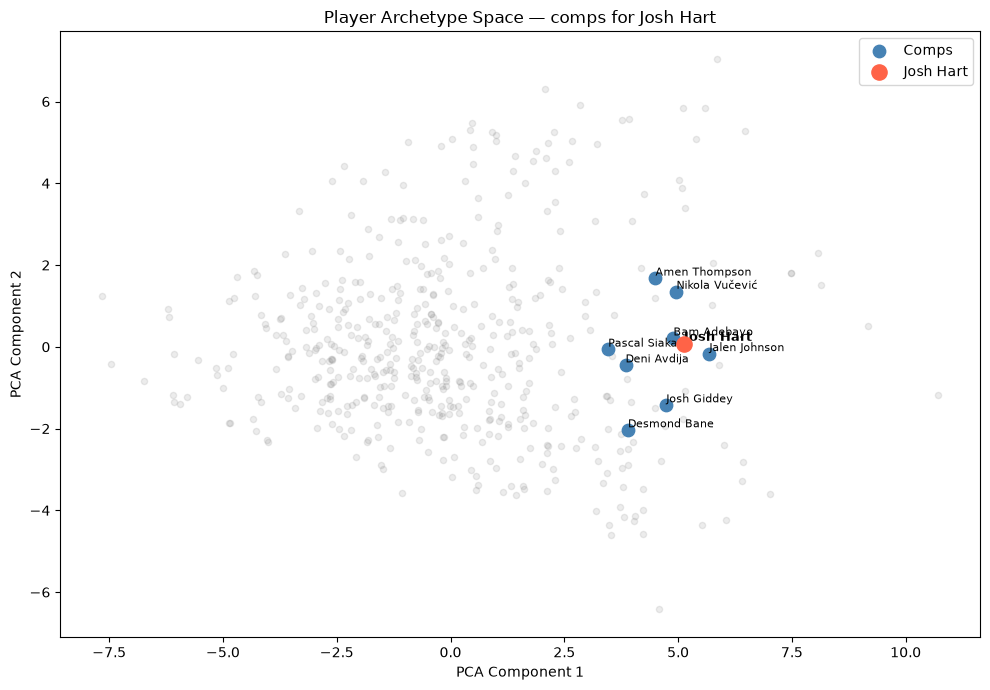

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

QUERY_PLAYER = "Josh Hart"
N_COMPS = 8

# Reduce to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# Get query player index
mask = valid_df['PLAYER_NAME'].str.lower().str.contains(QUERY_PLAYER.lower())
query_idx = valid_df[mask].index[0]

# Get comp indices
comps = find_similar_players(
    QUERY_PLAYER, df, scaler, knn, X_scaled, valid_df, feature_cols, n=N_COMPS
)
comp_names = comps['PLAYER_NAME'].tolist()
comp_mask = valid_df['PLAYER_NAME'].isin(comp_names)
comp_indices = valid_df[comp_mask].index

fig, ax = plt.subplots(figsize=(10, 7))

# All players (background)
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.15, s=20, color='gray')

# Comps
ax.scatter(X_2d[comp_indices, 0], X_2d[comp_indices, 1],
           color='steelblue', s=80, zorder=3, label='Comps')
for i in comp_indices:
    ax.annotate(valid_df.loc[i, 'PLAYER_NAME'],
                (X_2d[i, 0], X_2d[i, 1]),
                fontsize=8, ha='left', va='bottom')

# Query player
ax.scatter(X_2d[query_idx, 0], X_2d[query_idx, 1],
           color='tomato', s=120, zorder=4, label=QUERY_PLAYER)
ax.annotate(QUERY_PLAYER,
            (X_2d[query_idx, 0], X_2d[query_idx, 1]),
            fontsize=9, fontweight='bold', ha='left', va='bottom')

ax.set_title(f"Player Archetype Space — comps for {QUERY_PLAYER}")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend()
plt.tight_layout()
plt.show()

## Step 7 — Free agent filter (optional)
Paste in a list of free agent names to see which current players they comp to.

In [15]:
FREE_AGENTS = [
    "Jimmy Butler",
    "Klay Thompson",
    "Paul George",
]

results = {}
for fa in FREE_AGENTS:
    try:
        comps = find_similar_players(
            fa, df, scaler, knn, X_scaled, valid_df, feature_cols, n=5
        )
        results[fa] = comps
        print(f"\n=== {fa} ===")
        print(comps[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'PTS', 'REB', 'AST', 'TS_PCT', 'similarity_distance']].to_string(index=False))
    except ValueError as e:
        print(f"\nSkipping {fa}: {e}")


=== Jimmy Butler ===
       PLAYER_NAME TEAM_ABBREVIATION  PTS  REB  AST  TS_PCT  similarity_distance
  Payton Pritchard               BOS 14.3  3.8  3.5   0.633             3.353012
     Pascal Siakam               IND 20.2  6.9  3.4   0.599             3.671244
      Jrue Holiday               BOS 11.1  4.3  3.9   0.565             3.679063
     Austin Reaves               LAL 20.2  4.5  5.8   0.616             3.736397
Brandin Podziemski               GSW 11.7  5.1  3.4   0.557             3.835258

=== Klay Thompson ===
      PLAYER_NAME TEAM_ABBREVIATION  PTS  REB  AST  TS_PCT  similarity_distance
      Gradey Dick               TOR 14.4  3.6  1.8   0.543             1.444445
      Buddy Hield               GSW 11.1  3.2  1.6   0.560             1.588666
Julian Champagnie               SAS  9.9  3.9  1.4   0.577             1.589857
     Max Christie               DAL  9.6  3.3  1.9   0.570             1.611987
Bogdan Bogdanović               LAC 10.8  2.9  2.7   0.559           